In [1]:
import pandapower as pp
import pandapower.networks as pn
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
# 1. INITIALIZE THE BASE NETWORK
net = pn.case33bw()

In [3]:
# 2. APPLY "ACTIVE GRID" ENHANCEMENTS FROM THE PAPER
# A. Add Distributed Generation (DG) Units (0.2 MW each)
dg_buses = [17, 21, 24, 32]
for bus in dg_buses:
    pp.create_sgen(net, bus=bus, p_mw=0.2, q_mvar=0, name=f"DG_Bus_{bus+1}")

# B. Add Reactive Power Compensators (RPCs)
pp.create_shunt(net, bus=17, q_mvar=-0.4, name="RPC_Bus_18")
pp.create_shunt(net, bus=32, q_mvar=-0.6, name="RPC_Bus_33")

# C. Add Switchable Tie-Lines (Initialized as out of service)
pp.create_line_from_parameters(net, from_bus=20, to_bus=7, length_km=1, r_ohm_per_km=2.0, x_ohm_per_km=2.0, c_nf_per_km=0, max_i_ka=1, name="TieLine_33", in_service=False)
pp.create_line_from_parameters(net, from_bus=11, to_bus=21, length_km=1, r_ohm_per_km=2.0, x_ohm_per_km=2.0, c_nf_per_km=0, max_i_ka=1, name="TieLine_34", in_service=False)
pp.create_line_from_parameters(net, from_bus=24, to_bus=28, length_km=1, r_ohm_per_km=0.5, x_ohm_per_km=0.5, c_nf_per_km=0, max_i_ka=1, name="TieLine_35", in_service=False)

np.int64(39)

In [4]:
net

This pandapower network includes the following parameter tables:
   - bus (33 elements)
   - load (32 elements)
   - sgen (4 elements)
   - shunt (2 elements)
   - ext_grid (1 element)
   - line (40 elements)
   - poly_cost (1 element)

In [5]:
# 3. APPLY SYNTHETIC GPS COORDINATES (TAIWAN MAPPING)
# Initialize dataframe
net.bus_geodata = pd.DataFrame(columns=['x', 'y'], index=net.bus.index)

# Build topology graph using NetworkX
G = nx.Graph()
G.add_edges_from(net.line[['from_bus', 'to_bus']].values)

# Calculate layout
pos = nx.kamada_kawai_layout(G)
for bus_id, coords in pos.items():
    net.bus_geodata.loc[bus_id, 'x'] = coords[0]
    net.bus_geodata.loc[bus_id, 'y'] = coords[1]

# Scale and shift to Linbian, Taiwan
base_lat, base_lng = 22.434, 120.516
x_min, x_max = net.bus_geodata.x.min(), net.bus_geodata.x.max()
y_min, y_max = net.bus_geodata.y.min(), net.bus_geodata.y.max()

x_range = x_max - x_min if x_max != x_min else 1
y_range = y_max - y_min if y_max != y_min else 1

net.bus_geodata.x = base_lng + ((net.bus_geodata.x - x_min) / x_range - 0.5) * 0.045
net.bus_geodata.y = base_lat + ((net.bus_geodata.y - y_min) / y_range - 0.5) * 0.045

print("Enhanced Active Microgrid successfully initialized in Taiwan!")

Enhanced Active Microgrid successfully initialized in Taiwan!


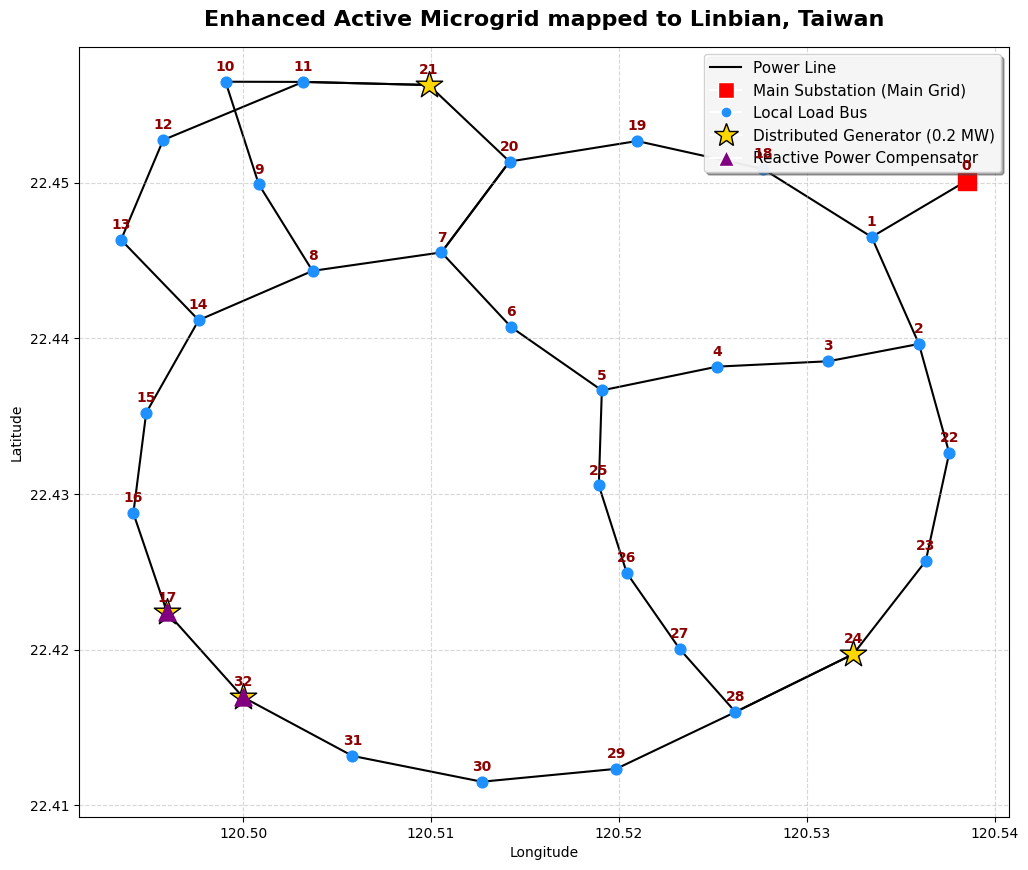

In [6]:
fig, ax = plt.subplots(figsize=(12, 10))

# 1. Draw the Power Lines
for idx, line in net.line.iterrows():
    fb, tb = line['from_bus'], line['to_bus']
    if fb in net.bus_geodata.index and tb in net.bus_geodata.index:
        fx, fy = net.bus_geodata.loc[fb, ['x', 'y']]
        tx, ty = net.bus_geodata.loc[tb, ['x', 'y']]
        ax.plot([fx, tx], [fy, ty], color='black', linewidth=1.5, zorder=1)

# 2. Draw Load Buses (Blue dots)
ax.scatter(net.bus_geodata['x'], net.bus_geodata['y'], 
           color='dodgerblue', s=60, zorder=2, label='Load Bus')

# 3. Draw Substation at Bus 0 (Red square)
sub_x, sub_y = net.bus_geodata.loc[0, ['x', 'y']]
ax.scatter(sub_x, sub_y, color='red', marker='s', s=150, zorder=3)

# 4. Draw DGs (Gold stars)
dg_buses = net.sgen.bus.values
dg_x, dg_y = net.bus_geodata.loc[dg_buses, 'x'], net.bus_geodata.loc[dg_buses, 'y']
ax.scatter(dg_x, dg_y, color='gold', marker='*', s=400, edgecolor='black', zorder=4)

# 5. Draw RPCs (Purple triangles)
shunt_buses = net.shunt.bus.values
shunt_x, shunt_y = net.bus_geodata.loc[shunt_buses, 'x'], net.bus_geodata.loc[shunt_buses, 'y']
ax.scatter(shunt_x, shunt_y, color='purple', marker='^', s=150, zorder=5)

# 6. Add Bus Numbers
for bus_id in net.bus_geodata.index:
    x = net.bus_geodata.loc[bus_id, 'x']
    y = net.bus_geodata.loc[bus_id, 'y']
    ax.text(x, y + 0.0007, str(bus_id), color='darkred', fontsize=10, 
            fontweight='bold', ha='center', zorder=6)

# 7. Build Custom Legend
custom_legend = [
    Line2D([0], [0], color='black', lw=1.5, label='Power Line'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='red', markersize=12, label='Main Substation (Main Grid)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='dodgerblue', markersize=8, label='Local Load Bus'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='gold', markeredgecolor='black', markersize=18, label='Distributed Generator (0.2 MW)'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='purple', markersize=12, label='Reactive Power Compensator')
]
ax.legend(handles=custom_legend, loc='upper right', fontsize=11, framealpha=0.9, shadow=True)

# 8. Formatting
ax.set_title("Enhanced Active Microgrid mapped to Linbian, Taiwan", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()